Iteration 0, Cost: 0.4902842548564068
Iteration 100, Cost: 0.0758825706270806
Iteration 200, Cost: 0.020361167713443724
Iteration 300, Cost: 0.012922428203416783
Iteration 400, Cost: 0.011925788302510296
Iteration 500, Cost: 0.011792258812636378
Iteration 600, Cost: 0.011774368574999116
Iteration 700, Cost: 0.011771971646777348
Iteration 800, Cost: 0.011771650507113533
Iteration 900, Cost: 0.011771607480925794
Final model: y = 1.95x + 3.22


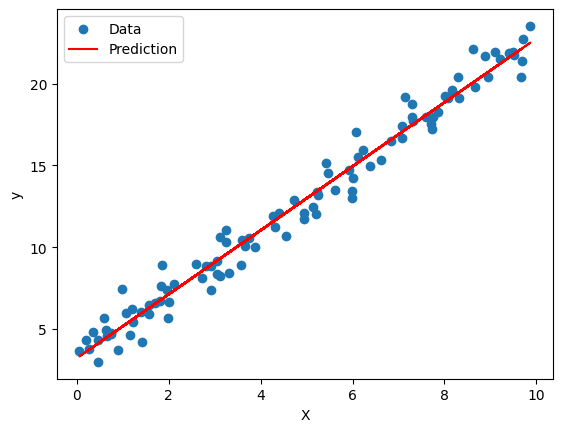

In [2]:
import numpy as np
# Generate or use a dataset
# Example: y = 2x + 3 + noise
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 samples between 0 and 10
y = 2 * X + 3 + np.random.randn(100, 1)  # Add some noise

# Normalize the data for faster convergence
X_mean, X_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X_norm = (X - X_mean) / X_std
y_norm = (y - y_mean) / y_std

# Initialize parameters
w = 0  # weight
b = 0  # bias
learning_rate = 0.01
num_iterations = 1000

# Hypothesis function
def predict(X, w, b):
    return w * X + b

# Cost function
def compute_cost(X, y, w, b):
    m = len(y)
    predictions = predict(X, w, b)
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)

# Gradient Descent
for i in range(num_iterations):
    m = len(y_norm)
    predictions = predict(X_norm, w, b)
    
    # Compute gradients
    dw = (1 / m) * np.sum((predictions - y_norm) * X_norm)
    db = (1 / m) * np.sum(predictions - y_norm)
    
    # Update weights and bias
    w -= learning_rate * dw
    b -= learning_rate * db
    
    # Optionally print cost every 100 iterations
    if i % 100 == 0:
        cost = compute_cost(X_norm, y_norm, w, b)
        print(f"Iteration {i}, Cost: {cost}")

# Denormalize parameters
w_final = w * (y_std / X_std)
b_final = b * y_std + y_mean - w_final * X_mean

print(f"Final model: y = {w_final:.2f}x + {b_final:.2f}")

# Plot the data and the model
plt.scatter(X, y, label="Data")
plt.plot(X, predict(X, w_final, b_final), color="red", label="Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()
import matplotlib.pyplot as plt

